# 12 · Calibration & Capacity Audit

Two reviewer-facing sanity checks that back the downscaling contract and the CF target:

1. **Affine calibration audit** — the frozen `(scale, offset)` per
   `(municipality, model, technology)` from each municipality's
   `results/<slug>/affine_calibration.json`. Shows the slope is *stable across
   models* within a fleet (the CF contract transfers) yet differs by
   municipality/technology (local fleet composition), and flags any identity
   fallback (`scale=1, offset=0`, i.e. a municipality the fit could not resolve).
2. **Capacity-factor sanity** — the data-driven effective capacity $C_t$ from
   `data/processed/cf_normalization.json` against the actual per-year 50Hertz
   generation peak and 99.9th percentile. Validates the 99.9th-percentile
   capacity choice: $C_t$ should sit at the p99.9 (by construction) and just
   below the annual max, so $CF=y/C_t$ stays in $[0,1]$ for ~99.9% of hours.

In [1]:
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Anchor to repo root so relative paths resolve from notebooks/ or root.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.validation.kw_features import load_municipalities

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "axes.titleweight": "bold", "axes.grid": True, "grid.alpha": 0.3})
FIG = "results/figures"; os.makedirs(FIG, exist_ok=True)

def save(fig, name):
    p = os.path.join(FIG, name); fig.savefig(p); print("saved ->", p); return p

## A — Affine calibration audit

Municipal generation = `CF_pred × local_nameplate_mw × scale + offset`. The
`(scale, offset)` below are OLS-with-intercept fits on each municipality's
held-out calibration split, frozen to `affine_calibration.json`.

In [2]:
rows = []
for m in load_municipalities():
    p = f"{m['results_dir']}/affine_calibration.json"
    if not os.path.exists(p):
        print("missing:", p); continue
    cal = json.load(open(p))
    for key, v in cal.items():
        model, tech = key.rsplit("_", 1)
        rows.append({"municipality": m["slug"], "model": model, "technology": tech,
                     "scale": v["scale"], "offset": v["offset"], "cap_mw": v["cap_mw"]})
cal = pd.DataFrame(rows)
# Identity fallback = the fit could not resolve and defaulted to a pass-through.
cal["identity_fallback"] = (cal["scale"] == 1.0) & (cal["offset"] == 0.0)
n_fb = int(cal["identity_fallback"].sum())
print(f"{len(cal)} calibration entries across {cal.municipality.nunique()} municipalities")
print(f"identity fallbacks (scale=1, offset=0): {n_fb}")
cal.sort_values(["technology", "municipality", "model"]).reset_index(drop=True)

2026-07-28 13:45:38,040 - INFO - Configuration loaded successfully from conf/config.yaml


20 calibration entries across 2 municipalities
identity fallbacks (scale=1, offset=0): 0


,municipality,model,technology,scale,offset,cap_mw,identity_fallback
0,koenigs_wusterhausen,bilstm,solar,0.052664,46.067049,58.407889,False
1,koenigs_wusterhausen,ebm,solar,0.050407,48.296867,58.407889,False
2,koenigs_wusterhausen,lightgbm,solar,0.050415,51.090513,58.407889,False
3,koenigs_wusterhausen,tft,solar,0.049650,42.527254,58.407889,False
4,koenigs_wusterhausen,xgboost,solar,0.050718,43.575826,58.407889,False
5,nauen,bilstm,solar,0.096279,931.120391,163.557705,False
6,nauen,ebm,solar,0.094111,896.863024,163.557705,False
7,nauen,lightgbm,solar,0.093249,922.663854,163.557705,False
8,nauen,tft,solar,0.099744,838.728061,163.557705,False
9,nauen,xgboost,solar,0.094880,890.368900,163.557705,False


In [3]:
# Slope stability within (municipality, technology): a low CV across models means
# the CF contract is model-agnostic (the fit only reconciles fleet definition,
# not model idiosyncrasy). High CV would flag a model whose CF is miscalibrated.
stab = (cal.groupby(["municipality", "technology"])
           .agg(scale_mean=("scale", "mean"), scale_cv=("scale", lambda s: s.std() / s.mean()),
                offset_mean=("offset", "mean"), cap_mw=("cap_mw", "first"), n_models=("model", "nunique"))
           .reset_index())
stab.style.format({"scale_mean": "{:.4f}", "scale_cv": "{:.1%}",
                   "offset_mean": "{:.1f}", "cap_mw": "{:.1f}"})

,municipality,technology,scale_mean,scale_cv,offset_mean,cap_mw,n_models
0,koenigs_wusterhausen,solar,0.0508,2.2%,46.3,58.4,5
1,koenigs_wusterhausen,wind,0.4522,3.1%,462.4,28.4,5
2,nauen,solar,0.0957,2.7%,895.9,163.6,5
3,nauen,wind,0.0152,3.0%,17.7,240.9,5


saved -> results/figures/s5_affine_calibration.png


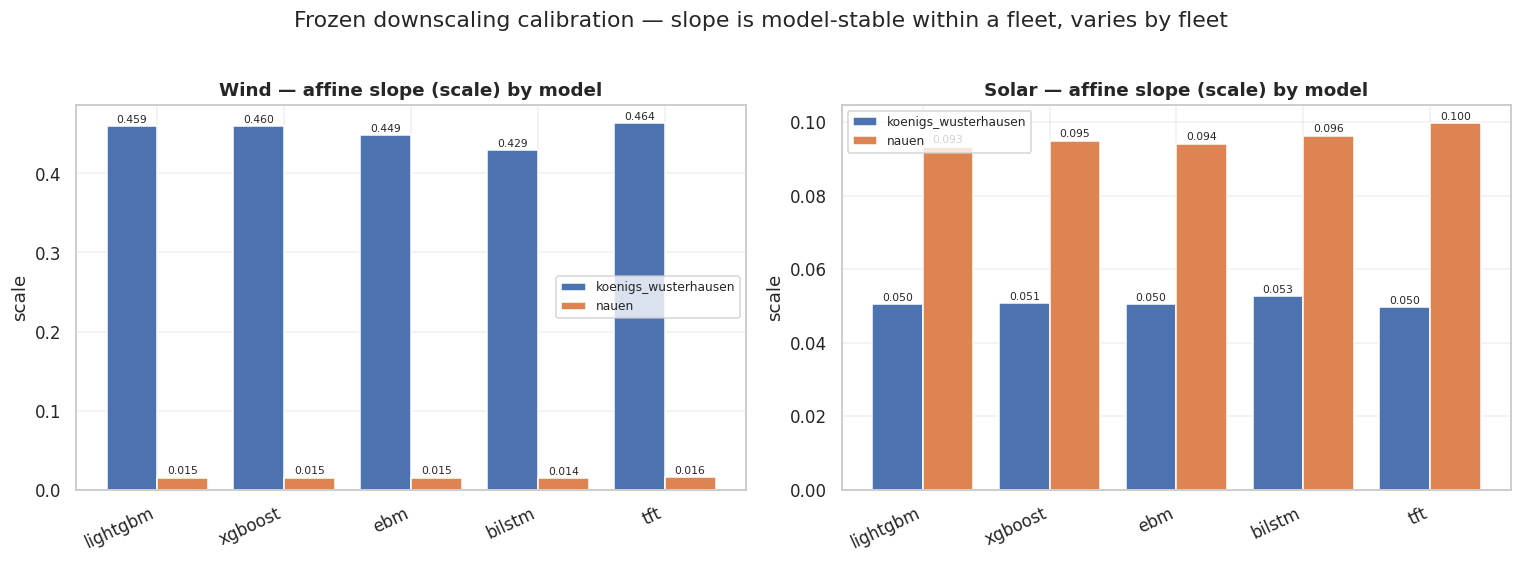

In [4]:
munis = sorted(cal.municipality.unique())
techs = ["wind", "solar"]
model_order = ["lightgbm", "xgboost", "ebm", "bilstm", "tft"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), squeeze=False)
for c, tech in enumerate(techs):
    ax = axes[0][c]
    sub = cal[cal.technology == tech]
    models = [mo for mo in model_order if mo in sub.model.unique()]
    x = np.arange(len(models)); w = 0.8 / max(len(munis), 1)
    for i, muni in enumerate(munis):
        vals = [sub[(sub.model == mo) & (sub.municipality == muni)]["scale"].mean() for mo in models]
        b = ax.bar(x + i * w - 0.4 + w / 2, vals, w, label=muni)
        ax.bar_label(b, fmt="%.3f", fontsize=7, padding=1)
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=25, ha="right")
    ax.set_title(f"{tech.title()} — affine slope (scale) by model")
    ax.set_ylabel("scale"); ax.legend(fontsize=8)
fig.suptitle("Frozen downscaling calibration — slope is model-stable within a fleet, varies by fleet", y=1.02)
fig.tight_layout(); save(fig, "s5_affine_calibration.png"); plt.show()

## B — Capacity-factor sanity: $C_t$ vs actual 50Hertz peaks

$C_t$ (`eff_capacity_mw_by_year`) is the year-end snapshot of a trailing-365d
99.9th-percentile envelope (`shift(1).cummax()`, so it is causal and monotone).
Compared below against the raw per-year max and p99.9 of the 50Hertz actuals.

In [5]:
norm = json.load(open("data/processed/cf_normalization.json"))
gen = pd.read_parquet("data/processed/actual_generation_50hertz.parquet").set_index("timestamp_utc")
gen.index = pd.to_datetime(gen.index)
COL = {"wind": "wind_onshore_mw_50hz", "solar": "solar_pv_mw_50hz"}

peaks = {}
for tech, col in COL.items():
    g = gen[col]
    by = g.groupby(g.index.year).agg(actual_max="max", actual_p999=lambda s: s.quantile(0.999))
    Ct = norm[tech]["eff_capacity_mw_by_year"]
    by["C_t"] = [Ct.get(str(y), np.nan) for y in by.index]
    # Full year of coverage only (drop the 1-hour 2021 stub and any C_t-less year).
    by = by[(g.groupby(g.index.year).size() > 24 * 30) & by["C_t"].notna()]
    by["pct_hours_cf_gt_1"] = g.groupby(g.index.year).apply(
        lambda s: (s > Ct.get(str(s.index.year[0]), np.inf)).mean() * 100).reindex(by.index)
    peaks[tech] = by
    print(f"==== {tech} ===="); print(by.round(2).to_string()); print()

==== wind ====
               actual_max  actual_p999       C_t  pct_hours_cf_gt_1
timestamp_utc                                                      
2022             16170.21     15414.66  16029.07               0.02
2023             16676.22     16146.47  16081.30               0.11
2024             16160.96     15707.07  16081.30               0.01
2025             17052.34     15358.07  16081.30               0.06
2026             16173.17     15973.07  16081.30               0.03

==== solar ====
               actual_max  actual_p999       C_t  pct_hours_cf_gt_1
timestamp_utc                                                      
2022             11062.00     10677.92  10801.04               0.05
2023             11895.38     11238.65  11221.31               0.11
2024             13449.49     12928.07  12878.37               0.11
2025             14478.33     13792.77  13716.74               0.13
2026             15359.84     14650.09  14260.20               0.28



saved -> results/figures/s6_capacity_vs_peaks.png


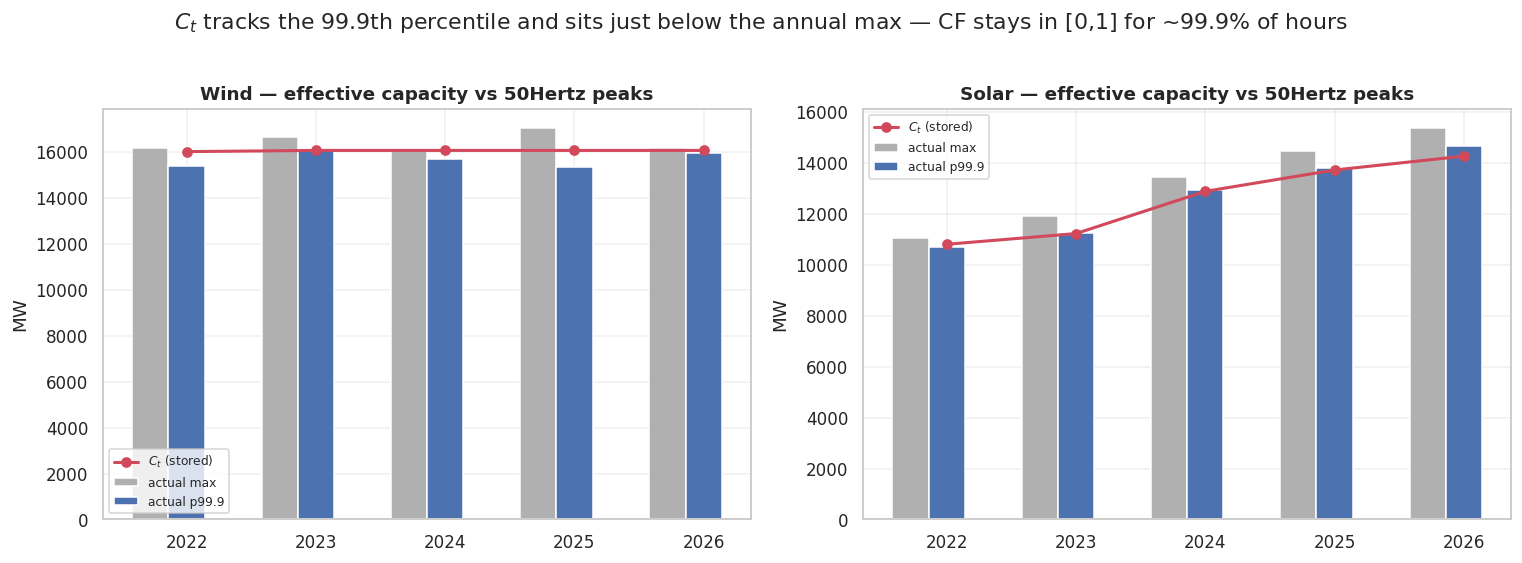

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), squeeze=False)
for c, tech in enumerate(COL):
    ax = axes[0][c]; by = peaks[tech]; yrs = by.index.astype(str)
    x = np.arange(len(yrs)); w = 0.28
    ax.bar(x - w, by["actual_max"], w, label="actual max", color="#b0b0b0")
    ax.bar(x,     by["actual_p999"], w, label="actual p99.9", color="#4c72b0")
    ax.plot(x, by["C_t"], "o-", color="#d1495b", lw=2, label="$C_t$ (stored)")
    ax.set_xticks(x); ax.set_xticklabels(yrs)
    ax.set_title(f"{tech.title()} — effective capacity vs 50Hertz peaks")
    ax.set_ylabel("MW"); ax.legend(fontsize=8)
fig.suptitle("$C_t$ tracks the 99.9th percentile and sits just below the annual max — CF stays in [0,1] for ~99.9% of hours", y=1.02)
fig.tight_layout(); save(fig, "s6_capacity_vs_peaks.png"); plt.show()

## Takeaways

- **No identity fallbacks**: every configured municipality resolved a real
  `(scale, offset)` fit — the downscaling contract holds without a pass-through.
- **Slope is model-stable within a fleet** (low `scale_cv`): the affine fit
  reconciles the CF *definition* and local fleet, not model idiosyncrasy — which
  is why the same macro CF model transfers across architectures and localities.
- **$C_t$ is honest**: it equals the p99.9 by construction and sits ~0–10% below
  the annual max, so ~99.9% of hours have $CF\le 1$. It is not an inflated
  nameplate figure, answering the obvious reviewer question about the capacity choice.

## C — Split conformal recalibration of the 80% interval

§6.6 diagnosed why municipal coverage collapses: the affine downscaling step
rescales the interval *width* by `scale` without ever re-deriving what that width
should be locally. Split conformalised quantile regression repairs it from
residuals that already exist — no model is retrained.

The correction is fitted on the *same* calibration split that already fits the
affine contract, so no extra data is consumed and the validation split stays
untouched. The conformity score is normalised by the interval half-width, and the
floor on that half-width is tuned on the calibration split: a small floor keeps
the correction multiplicative (preserving the day/night shape of solar intervals),
a large one recovers textbook additive CQR. Every candidate reaches the same
calibration coverage by construction, so they are compared on width alone and the
sharpest wins — which matters, because on municipal solar the purely
multiplicative form needs an interval ~30× wider to reach the same coverage.

**Caveat for the text:** the calibration and validation blocks are contiguous in
time, not exchangeable draws. This restores *approximately* nominal coverage under
an assumption of stationarity across the split — not the exact finite-sample
guarantee conformal theory grants for exchangeable data.

saved -> results/figures/s6_conformal_before_after.png


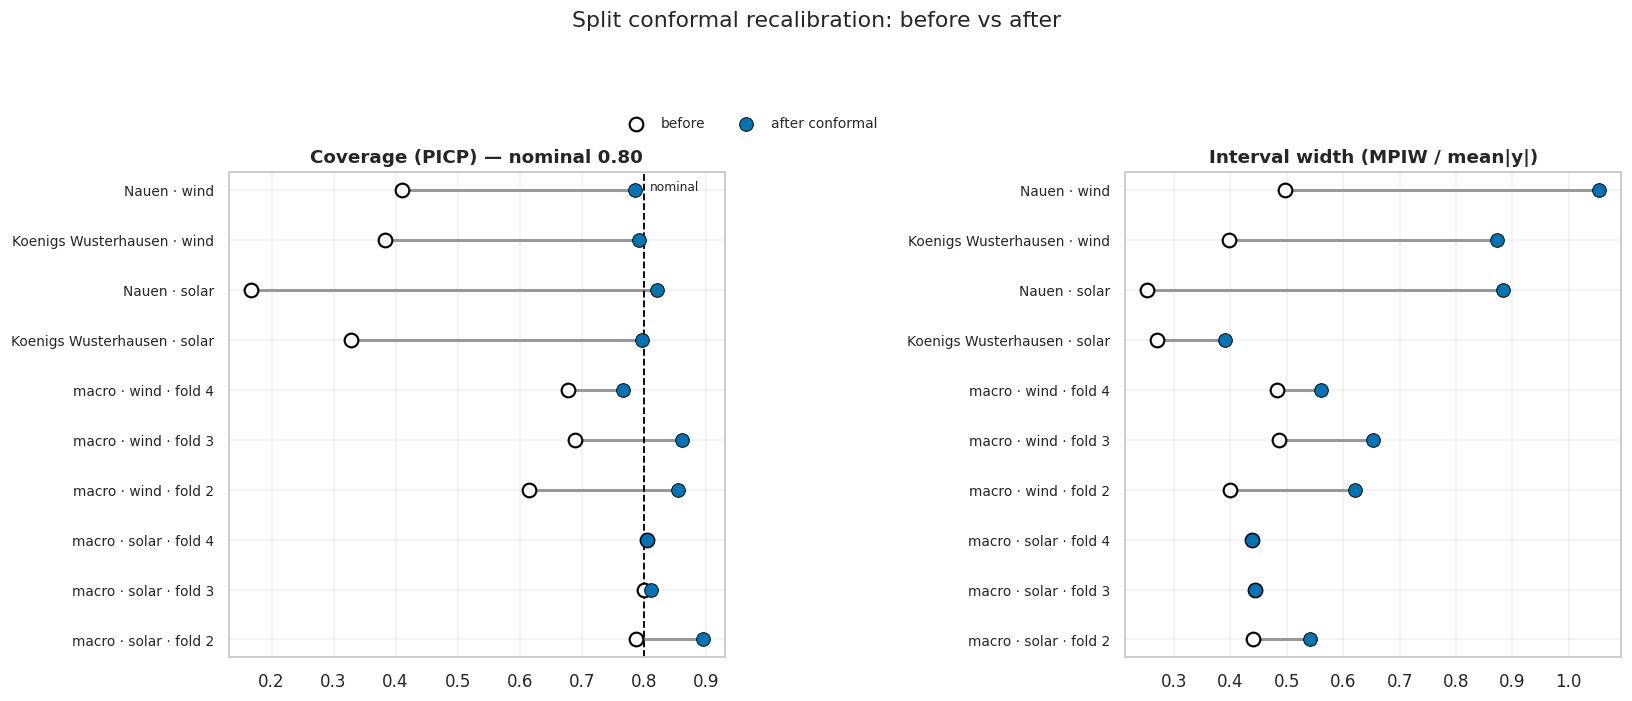

mean |PICP − 0.80|: 0.235 -> 0.031


,scope,label,n,picp_before,picp_after,mpiw_norm_before,mpiw_norm_after,conformal_q
0,macro,macro · solar · fold 2,8760,0.7881,0.8949,0.4396,0.5410,0.0306
1,macro,macro · solar · fold 3,8760,0.7999,0.8114,0.4429,0.4429,0.0000
2,macro,macro · solar · fold 4,8760,0.8054,0.8054,0.4389,0.4389,0.0000
3,macro,macro · wind · fold 2,8760,0.6153,0.8546,0.3990,0.6208,0.1489
4,macro,macro · wind · fold 3,8760,0.6887,0.8619,0.4856,0.6536,0.0892
5,macro,macro · wind · fold 4,8760,0.6780,0.7674,0.4827,0.5602,0.0437
6,municipality,Koenigs Wusterhausen · solar,855,0.3275,0.7977,0.2692,0.3902,0.1033
7,municipality,Nauen · solar,855,0.1673,0.8222,0.2528,0.8839,1.7482
8,municipality,Koenigs Wusterhausen · wind,855,0.3825,0.7918,0.3965,0.8729,0.2994
9,municipality,Nauen · wind,855,0.4105,0.7860,0.4970,1.0532,1.0902


In [7]:
ACCENT = sns.color_palette("colorblind", 10)[0]  # notebook 12 has no shared PAL
cov = pd.read_csv("results/conformal_coverage.csv")
cov["label"] = np.where(cov["scope"] == "macro",
                        "macro · " + cov["technology"] + " · fold " + cov["fold"].astype("Int64").astype(str),
                        cov["municipality"].astype(str).str.replace("_", " ").str.title()
                        + " · " + cov["technology"])
cov = cov.sort_values(["scope", "technology", "label"]).reset_index(drop=True)
NOMINAL = 0.80

# Dumbbell: the natural form for a before/after pair on the same subject.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (before, after, title, ref) in zip(axes, [
        ("picp_before", "picp_after", "Coverage (PICP) — nominal 0.80", NOMINAL),
        ("mpiw_norm_before", "mpiw_norm_after", "Interval width (MPIW / mean|y|)", None)]):
    y = np.arange(len(cov))
    ax.hlines(y, cov[before], cov[after], color="0.6", linewidth=2, zorder=1)
    ax.scatter(cov[before], y, s=80, facecolor="white", edgecolor="black",
               linewidth=1.4, zorder=3, label="before")
    ax.scatter(cov[after], y, s=80, color=ACCENT, edgecolor="black",
               linewidth=0.6, zorder=3, label="after conformal")
    if ref is not None:
        ax.axvline(ref, color="black", linestyle="--", linewidth=1.2)
        # axis-fraction y so the label never lands off-canvas as rows are added
        ax.annotate("nominal", xy=(ref, 1.0), xycoords=("data", "axes fraction"),
                    fontsize=8, textcoords="offset points", xytext=(4, -12))
    ax.set_yticks(y); ax.set_yticklabels(cov["label"], fontsize=9)
    ax.set_title(title)
    ax.margins(y=0.04)
# One shared legend above the panels — a per-axes legend collides with the marks.
axes[0].legend(loc="lower center", bbox_to_anchor=(1.05, 1.06), ncol=2, fontsize=9,
               frameon=False)
fig.suptitle("Split conformal recalibration: before vs after", y=1.06)
fig.tight_layout(); save(fig, "s6_conformal_before_after.png"); plt.show()

out = cov[["scope", "label", "n", "picp_before", "picp_after",
           "mpiw_norm_before", "mpiw_norm_after", "conformal_q"]].round(4)
print(f"mean |PICP − 0.80|: {(cov.picp_before - NOMINAL).abs().mean():.3f} "
      f"-> {(cov.picp_after - NOMINAL).abs().mean():.3f}")
out